# Simulations of compartmental models

There are interesting conceptual questions about simulating the models we've been discussing so far. How can we run a model in continuous time using the discrete data structures and logic of programming? The big conceptual jump one needs to make to do exact direct simulations of a continuous time process is to think of time in terms of number of events rather than temporal units. By discretely jumping from one event to the next, one can exactly follow the process in continuous time!

And for compartmental or mean-field models, this task is actually pretty easy! We do not need to track every possible agent of the system and check what they might do next. All agents in a given compartments are identical or indistinguishable. They all have the same possible transitions and all change states at the same rate. In this context, we therefore suggest using what is called a Next Reaction Method.

## Poisson processes

All of our mechanisms so far are defined solely by the rate at which they occur. Those rates are all the Greek letters in our ODEs and they represent the speed at which something might occur. More intuitively, the inverse of the rate corresponds to the *expected* time until the event occurs. For example, if a projectile moves toward a target at 2km/h, then it takes 1/2 hour per kilometer. Our rates are just measured in terms of event per unit time instead; so we can inverse them to get the expected time per event.

Thus, we can equivalently say that all of our mechanisms are defined based on the expected time until they occur. This is what we call [**Poisson processes**](https://en.wikipedia.org/wiki/Poisson_point_process) which have very specific [**statistical properties**](https://en.wikipedia.org/wiki/Exponential_distribution).

Three things are important to simplify the simulations of Poisson processes. First, the distribution of time to the next event is an exponential distribution of average equal to the inverse of the rate. Second, the rate at which any of $n$ Poisson processes happen is equal to the sum of the $n$ rates. Third, the probability that one of $n$ Poisson process happens first is equal to the ratio of its rate to the sum of all $n$ rates.

:::{note}
Proving properties of Poisson processes is a great way to get a better intuition about how they work.

To prove that the distribution of time until the next event of a Poisson process follows an exponential distribution, it is easier to take the limit of an equivalent discrete process. Divide every time unit in $T$ discrete time step. Let the probability that the event occurs at a given time step by the original rate divided by $T$. The distribution of timesteps until the event occurs then follows a geometric distribution, describing the number of Bernoulli trials necessary to get a success. Now take the limit of $T$ going to infinity and track the distribution using a Taylor series.

One can use a similar logic to prove that any of $n$ Poisson processes occur as a Poisson process with a rate equal to the sum of the $n$ individual rates. Just redefine success as the complementary probability of none of the $n$ processes happenning in a time step and solve for the distribution until anything happens.

To calculate the probability that one of $n$ Poisson processes is the first to happen, take the distribution of time $t$ until one of the $n-1$ other processes happen and ask what is the probability that the process of interest happenned before $t$ by using the cumulative distribution function of the exponential distribution. Integrate over all $t$.
:::

## Next Reaction Method

To simulate systems composed of Poisson processes, we thus focus on the time to the *next* event. One can then, 
* Evaluate all the rates $r_i(x,t)$ of all possible events $i$ as well as their sum $R = \sum_i r_i(x,t)$.
* Draw time $\tau$ to the next event from a total process occurring at rate $R$.
* Pick the exact event $i$ proportionally $r_i(x,t)$, record that event and repeat.

Reference: 
- Gibson and Bruck (2000), **_Efficient Exact Stochastic Simulation of Chemical Systems with Many Species and Many Channels_** {cite}`gibson2000efficient`

## Cloning factory example

Let's simulate the cloning factory model. Agents enter a building atrate $\alpha$. Therein, they clone themselves at rate $\gamma$ or simply leave at rate $\beta$. The compartmental representation of this model was

![compartment_schematic3](assets/png/schematic3.png)

In simulation code, we need to track every variable as we do in our ODEs (or at least, every degree of freedom). We will thus track the number of agents $E$ in the exterior world as well as the number $N$ in the cloning factory. At a certain rate,

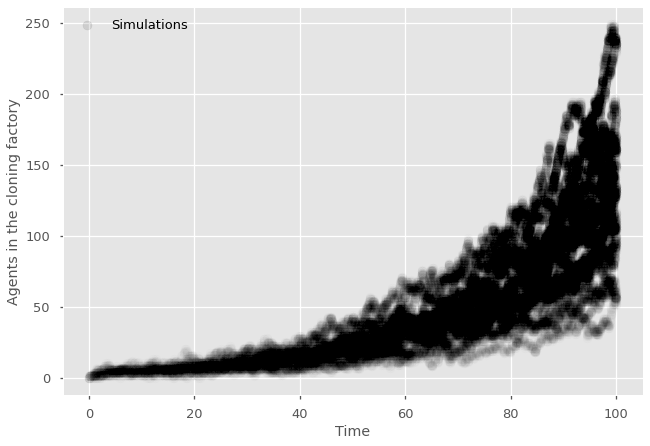

In [20]:
import random
import matplotlib.pyplot as plt
import numpy as np
plt.style.use(['ggplot', 'seaborn-talk'])

#parameters
alpha = 1/4
beta = 1/2
gamma = 1/10

#observables
history = np.zeros(1)
times = np.zeros(1)

#for each simulation
for sims in range(25):
    
    #initial conditions
    E = 10; N = 0
    time = 0
    
    #for each generation
    while time < 100:
        
        #calculate total rate R
        R_enter = E*alpha
        R_exit = N*beta
        R_clone = N*gamma
        R = R_enter + R_exit + R_clone
        
        #draw time to next event and event type
        tau = np.random.exponential(scale=1/R)
        random_number = random.random()
        if random_number < R_enter/R: #entrance
            E-=1
            N+=1
        elif random_number < (R_enter+R_exit)/R: #exit
            E+=1
            N-=1
        else: #cloning
            N+=1
            
        #update history
        time = time+tau
        history = np.append(history, N)
        times = np.append(times, time)
        
#print time series
plt.scatter(times,history, marker="o", color='black', alpha=0.01)
    
#Add null simulation with label in legend and label the axes
plt.scatter(0,0, marker="o", color='black', alpha=0.10, label='Simulations')
plt.legend(frameon=False)
plt.ylabel('Agents in the cloning factory')
plt.xlabel('Time')
plt.show()

## Comparison with mathematical model

We have previously written the ODEs for the system as:

$$
\begin{align}
\frac{d}{dt}E(t) &= \beta N(t) - \alpha E(t) \; , \\
\frac{d}{dt}N(t) &= \alpha E(t) + \gamma N(t) - \beta N(t) \; ,
\end{align}
$$

with a time-varying total population,

$$
\begin{align}
\frac{d}{dt}P(t) &= \frac{d}{dt}E(t) + \frac{d}{dt}P(t) = \gamma N(t) .
\end{align}
$$

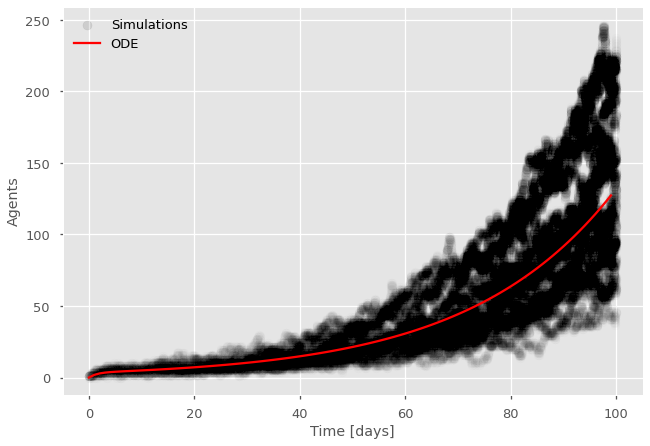

In [19]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['ggplot', 'seaborn-talk'])

# We will use the odeint routine
from scipy.integrate import odeint

# Differential equations
def ODEs(x, t, beta, alpha, gamma):
    """
    Derivative of the number of agents outside (E) and inside (N).

        * x is the state (array like): [E,N]
        * t is time (scalar)
        * beta is the exit rate
        * alpha is the entrance rate
        * gamma is the cloning rate
    """
    
    dx = 0*x #setting the data structure for every variable
    dx[0] = beta*x[1]-alpha*x[0] #derivative for E
    dx[1] = alpha*x[0] + (gamma - beta)*x[1] #derivative for N

    return dx

#parameters
alpha = 1/4
beta = 1/2
gamma = 1/10

# Time of observations
t_length = 100
t_vec = np.arange(0, t_length)

# Initial conditions
x_0 = np.zeros(3)
x_0[0] = 10; x_0[1] = 0

# Integration
G = lambda x, t: ODEs(x, t, beta, alpha, gamma)
x_path = odeint(G, x_0, t_vec)

# Plot
fig,ax = plt.subplots()
plt.scatter(times,history, marker="o", color='black', alpha=0.01)
plt.scatter(0,0, marker="o", color='black', alpha=0.10, label='Simulations')
ax.plot(t_vec, x_path[:,1], 'r', label='ODE')
plt.xlabel('Time')
plt.ylabel('Agents in the cloning factory')
ax.legend(frameon=False);

:::{note}
Mean-field models work by tracking the expected state of all degrees of freedom of a system, ignoring possible correlations between (or variance within) the degrees of freedom of the system.

If the higher-order information ignored is insignificant, we get an exact description of the expected state of the system. One can then assume some distribution this expectation (e.g., Gaussian if continuous or Poisson if discrete).
:::

## SEIR model example

We have previously defined the Susceptible-Exposed-Infectious-Recovered model with the following compartmental structure:

![compartment_schematic_SEIR](assets/png/schematic_SEIR.png)

We can implement a simulation as in the previous example, but we now must be careful: There are fixed points with no possible events! We need to handle the case where the disease goes extinct, i.e. $E=I=0$, very carefully. We'll add some condition to handle it.

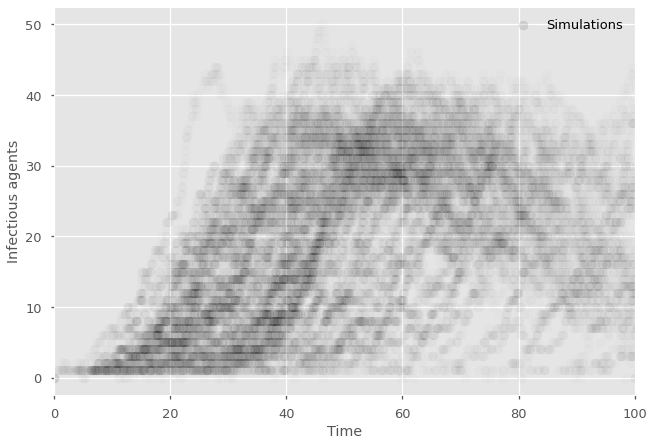

In [36]:
import random
import matplotlib.pyplot as plt
import numpy as np
plt.style.use(['ggplot', 'seaborn-talk'])

#parameters
alpha = 1/20
beta = 1/100
gamma = 1/20

#observables
history = np.zeros(1)
times = np.zeros(1)

#for each simulation
for sims in range(100):
    
    #initial conditions
    S = 100; E = 1; I = 0; R = 0
    time = 0
    
    #for each generation
    while time < 100:
        
        #calculate total rate R
        R_exposed = beta*S*I
        R_latent = alpha*E
        R_recover = gamma*I
        R = R_exposed + R_latent + R_recover
        
        #draw time to next event and event type
        if R>0.0: #There is now a fixed point!
            tau = np.random.exponential(scale=1/R)
        else:
            tau = np.inf
            history = np.append(history, 0.0)
            times = np.append(times, 100.0)
            break
        random_number = random.random()
        if random_number < R_exposed/R: #exposure
            S-=1
            E+=1
        elif random_number < (R_latent+R_exposed)/R: #latency over
            E-=1
            I+=1
        else: #recovery
            I-=1
            R+=1
            
        #update history
        time = time+tau
        history = np.append(history, I)
        times = np.append(times, time)
        
#print time series
plt.scatter(times,history, marker="o", color='black', alpha=0.01)
    
#Add null simulation with label in legend and label the axes
plt.scatter(0,0, marker="o", color='black', alpha=0.10, label='Simulations')
plt.legend(frameon=False)
plt.xlim([0,100])
plt.ylabel('Infectious agents')
plt.xlabel('Time')
plt.show()

And we can compare with the mean-field model again:

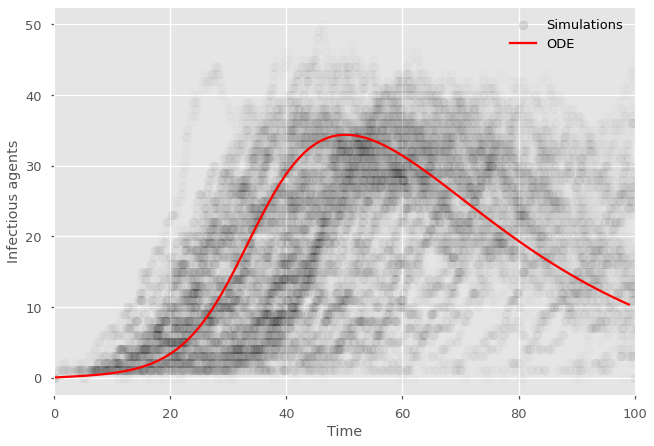

In [37]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use(['ggplot', 'seaborn-talk'])

# We will use the odeint routine
from scipy.integrate import odeint

# Differential equations
def ODEs(x, t, beta, alpha, gamma):
    """
    Derivative of the number of agents in S, E, I and R states.

        * x is the state (array like): [S,E,I,R]
        * t is time (scalar)
        * beta is the infection rate
        * alpha is the latency rate
        * gamma is the recovery rate
    """
    
    dx = 0*x #setting the data structure for every variable
    dx[0] = -beta*x[0]*x[2] #derivative for S
    dx[1] = beta*x[0]*x[2]-alpha*x[1] #derivative for E
    dx[2] = alpha*x[1] - gamma*x[2] #derivative for I
    dx[3] = gamma*x[2] #derivative for R

    return dx

#parameters
alpha = 1/20
beta = 1/100
gamma = 1/20

# Time of observations
t_length = 100
t_vec = np.arange(0, t_length)

# Initial conditions
x_0 = np.zeros(4)
x_0[0] = 100; x_0[1] = 1; x_0[2] = 0; x_0[3] = 0

# Integration
G = lambda x, t: ODEs(x, t, beta, alpha, gamma)
x_path = odeint(G, x_0, t_vec)

# Plot
fig,ax = plt.subplots()
plt.scatter(times,history, marker="o", color='black', alpha=0.01)
plt.scatter(0,0, marker="o", color='black', alpha=0.10, label='Simulations')
ax.plot(t_vec, x_path[:,2], 'r', label='ODE')
plt.xlim([0,100])
plt.xlabel('Time')
plt.ylabel('Infectious agents')
ax.legend(frameon=False);